# Make particle distribution plot for publication

Includes:
- ALHIC1901 228_4 and 230_4 distributions
- ALHIC1903 MIS 5e and 6 distributions
- ALHIC1901 distributions from Alissa and Jacob

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import loadmat
from dataclasses import dataclass


In [85]:
path_to_final_figures = '../../../paper/final_figures/'

# TOTAL_COUNTS_CSV = Path("../../data/broader_context/CC_Data/TotalCounts_Dates.csv")
# COULTER_SAMPLES_CSV = Path("../../data/broader_context/CC_Data/CoulterCounterSamples.csv")
# AUSTIN_1903_DIR = Path("../../data/broader_context/CC_Data/Austin CC/")
# AUSTIN_1901_DIR = Path("../../data/broader_context/CC_Data/Austin CC/ALHIC1901/")
# PLOT_OUTPUT = Path("Plots/PubFig_CoulterCounterMean.png")

BASAL_FILE = Path("../../data/sampling/coulter_counter/cc_data.xlsx")
ALHIC1903_mean_MIS5e = Path("../../data/broader_context/CC_Data/Austin CC/mean_MIS5e.mat")
ALHIC1903_mean_MIS6m = Path("../../data/broader_context/CC_Data/Austin CC/mean_MIS6.mat")
ALHIC1903_bins = Path("../../data/broader_context/CC_Data/Austin CC/bin_diam.mat")

ALHIC1901_avg_gt_154p8_file = Path("../../data/broader_context/CC_Data/Austin CC/ALHIC1901_avg_dVdlogD_TD_gt_154p8.mat")
ALHIC1901_avg_le_154p8_file = Path("../../data/broader_context/CC_Data/Austin CC/ALHIC1901_avg_dVdlogD_TD_le_154p8.mat")
ALHIC1901_diam_file = Path("../../data/broader_context/CC_Data/Austin CC/ALHIC1901_diam.mat")

In [86]:
# set fixed numbers
coarse_cutoff = 8 # cutoff ALHIC1901 basal data below this number
density = 2.62

## Define Functions and Classes

In [87]:
@dataclass
class stick_or_set:
    diam: np.ndarray
    mean: np.ndarray
    std: np.ndarray
    label: str


In [88]:
# get dV/dlnD from dataframe of counts (Works for basal data )
def get_dVdlnD(df,label):

    # # drop columns with diam below cutoff
    # df = df.loc[:, pd.to_numeric(df.columns) >= coarse_cutoff]

    #drop first n columns, where n is set by coarse_cutoff
    df = df.iloc[:, int(coarse_cutoff):]

    # bin edges from column names
    edges = pd.to_numeric(df.columns).to_numpy(dtype=float)

    # append final upper edge manually
    edges = np.append(edges, 30.0)

    # geometric-mean bin centers
    diam = np.sqrt(edges[:-1] * edges[1:])

    # log bin widths: now length N
    dlnD = np.diff(np.log(edges))

    # particle volume at each bin center
    vol_particle = (4.0 / 3.0) * np.pi * (diam / 2.0) ** 3

    # convert counts to volume
    volume = df * vol_particle

    # divide each column by its dlnD
    dVdlnD = volume / dlnD

    # compute mean and std across rows
    mean_psd = dVdlnD.mean(axis=0).to_numpy()
    std_psd = dVdlnD.std(axis=0).to_numpy()

    return stick_or_set(diam, mean_psd, std_psd, label)

In [89]:
def centers_to_edges(diam):
    # log-space edges from geometric-mean centers
    inner = np.sqrt(diam[:-1] * diam[1:])
    left = diam[0]**2 / inner[0]
    right = diam[-1]**2 / inner[-1]
    return np.concatenate(([left], inner, [right]))

## Load data

### We'll start with ALHIC1901 basal samples

In [90]:
basal = pd.read_excel(BASAL_FILE)

# subset the data by section and stick
basal_228_4_lic = basal[(basal["section"] == "228_4") & (basal["stick"] == "LIC")].copy()
basal_228_4_ric = basal[(basal["section"] == "228_4") & (basal["stick"] == "RIC")].copy()
basal_230_4 = basal[basal["section"] == "230_4"].copy()

# drop unnecessary columns
for _df in (basal_228_4_lic, basal_228_4_ric, basal_230_4):
    _df.drop(columns=["section", "stick","top_depth", "bottom_depth", "mid_depth"], inplace=True)

# compute dVdlnD for each subset
psd_228_4_lic = get_dVdlnD(basal_228_4_lic, "228_4_LIC")
psd_228_4_ric = get_dVdlnD(basal_228_4_ric, "228_4_RIC")
psd_230_4 = get_dVdlnD(basal_230_4, "230_4")   

### Now load ALHIC1903 samples from Austin

In [91]:
# get dV/dlnD from dataframe of counts (Works for Austin's 1903 data, which is already averaged and only has one row)
def get_dVdlnD_alhic1903(df,label):

    # bin edges from column names
    diam = pd.to_numeric(df.columns).to_numpy(dtype=float)

    # divide each column by its dlnD
    dVdlnD = df

    # there's only one row, so just take that row as the mean and set std to zero
    mean_psd = dVdlnD.iloc[0].to_numpy()
    std_psd = np.zeros_like(mean_psd)

    return stick_or_set(diam, mean_psd, std_psd, label)

In [92]:
mis5e_mat = loadmat(ALHIC1903_mean_MIS5e)
mis6_mat = loadmat(ALHIC1903_mean_MIS6m)
austin_bins = loadmat(ALHIC1903_bins)

mis5e_diam = mis5e_mat["mean_MIS5e"].flatten()
mis6_diam = mis6_mat["mean_MIS6"].flatten()
austin_diam = austin_bins["bin_diam"].flatten()

# convert to .csv format for use in dV/dlnD calculation
mis5e_df = pd.DataFrame(mis5e_mat["mean_MIS5e"].flatten()[None, :], columns=austin_diam)
mis6_df = pd.DataFrame(mis6_mat["mean_MIS6"].flatten()[None, :], columns=austin_diam)

# compute dV/dlnD for Austin's ALHIC1903 data
psd_mis5e = get_dVdlnD_alhic1903(mis5e_df, "ALHIC1903 MIS5e\n(Carter et al. 2026)")
psd_mis6 = get_dVdlnD_alhic1903(mis6_df, "ALHIC1903 MIS6\n(Carter et al. 2026)")

### Now load ALHIC1901 samples from Austin and Alissa

In [93]:
ALHIC1901_avg_gt_154p8_mat = loadmat(ALHIC1901_avg_gt_154p8_file)
ALHIC1901_avg_le_154p8_mat = loadmat(ALHIC1901_avg_le_154p8_file)
ALHIC1901_diam_mat = loadmat(ALHIC1901_diam_file)

alissa_bins = ALHIC1901_diam_mat["diam"].flatten()
alhic1901_deep = ALHIC1901_avg_gt_154p8_mat["avg_dVdlogD_TD_gt_154p8"].flatten()
alhic1901_shallow = ALHIC1901_avg_le_154p8_mat["avg_dVdlogD_TD_le_154p8"].flatten()    

# convert to .csv format for use in dV/dlnD calculation
alhic1901_deep_df = pd.DataFrame(alhic1901_deep[None, :], columns=alissa_bins)
alhic1901_shallow_df = pd.DataFrame(alhic1901_shallow[None, :], columns=alissa_bins)

# compute dV/dlnD for Alissa's ALHIC1901 data
psd_alhic1901_deep = get_dVdlnD_alhic1903(alhic1901_deep_df, "ALHIC1901 >154.8m\n(Choi et al. 2026)")
psd_alhic1901_shallow = get_dVdlnD_alhic1903(alhic1901_shallow_df, "ALHIC1901 <=154.8m\n(Choi et al. 2026)")

## Now let's plot the data

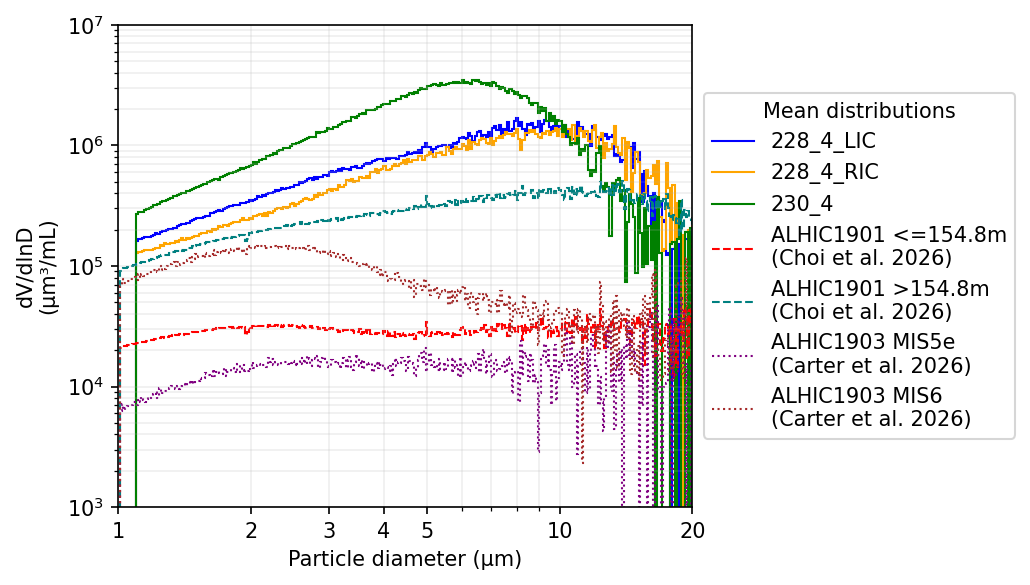

In [ ]:
uncertainty = False

# make figures
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# plot the ALHIC1901 basal PSDs with uncertainty envelopes
basal = [psd_228_4_lic, psd_228_4_ric, psd_230_4]
colors = ["#1f77b4", "#4aa3df", "#0b4f9c"]  # blue family
for psd, color in zip(basal, colors):
    y = psd.mean
    y_low = np.maximum(psd.mean - psd.std, 1e-12)  # positive for log scale
    y_high = psd.mean + psd.std
    edges = centers_to_edges(psd.diam)

    ax.stairs(y, edges, linewidth=1, label=psd.label, color=color)

    #optional uncertainty envelope (also stepped):
    if uncertainty:
        ax.fill_between(
            edges,
            np.r_[y_low, y_low[-1]],
            np.r_[y_high, y_high[-1]],
            step="post",
            alpha=0.2,
            color=color
        )

# plot the ALHIC1901 Austin PSDs split by TD
alhic1901 = [psd_alhic1901_shallow, psd_alhic1901_deep]
colors = ["#2ca02c", "#1b7f1b"]  # green family
for psd, color in zip(alhic1901, colors):
    y = psd.mean
    edges = centers_to_edges(psd.diam)
    ax.stairs(y, edges, linewidth=1, linestyle="--", label=psd.label, color=color)


# plot the ALHIC1903 PSDs without uncertainty envelopes
for psd, color in zip([psd_mis5e, psd_mis6], ["#ff7f0e", "#c25d00"]):
    y = psd.mean
    edges = centers_to_edges(psd.diam)
    ax.stairs(y, edges, linewidth=1, linestyle=":", label=psd.label, color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 20)
ax.set_ylim(1e3, 1e7)

xticks = [1, 2, 3, 4, 5, 10, 20]

ax.set_xticks(xticks)
ax.set_xticklabels([str(t) for t in xticks])

ax.set_xlabel("Particle diameter (µm)")
ax.set_ylabel("dV/dlnD\n(µm³/mL)")
ax.legend(title="Mean distributions", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
ax.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

### Same plot, but now let's try to remove the lines dwon to zero

In [98]:
def plot_stepped_with_gaps(ax, diam, y, lower_limit=1e3, **kwargs):
    """
    Plots a stepped line that fully skips segments below lower_limit.
    """
    # Calculate edges to mimic ax.stairs behavior
    edges = centers_to_edges(diam)
    
    # Mask y: any value below lower_limit becomes NaN
    # This prevents the vertical 'plunge' to the bottom of the axis
    y_masked = np.where(y >= lower_limit, y, np.nan)
    
    # To make ax.step look like ax.stairs, we repeat the last y value 
    # so it covers the final bin width
    y_plot = np.append(y_masked, y_masked[-1])
    
    return ax.step(edges, y_plot, where='post', **kwargs)

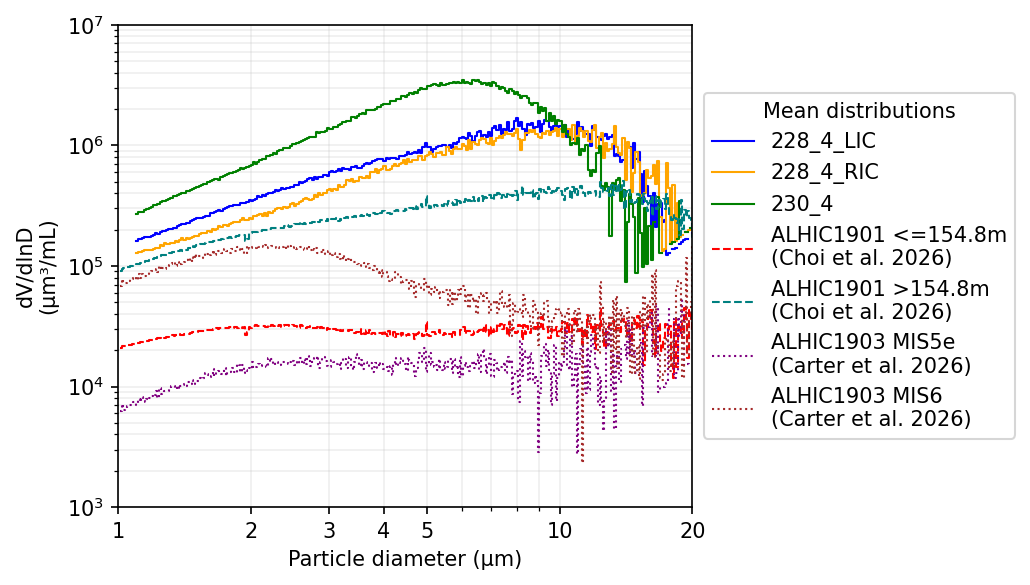

In [ ]:
uncertainty = False
lower_limit = 1e3

# make figures
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# plot the ALHIC1901 basal PSDs
basal = [psd_228_4_lic, psd_228_4_ric, psd_230_4]
colors = ["#1f77b4", "#4aa3df", "#0b4f9c"]  # blue family
for psd, color in zip(basal, colors):
    edges = centers_to_edges(psd.diam)
    
    # Custom function call
    plot_stepped_with_gaps(ax, psd.diam, psd.mean, lower_limit=lower_limit, 
                           linestyle='-', linewidth=1, label=psd.label, color=color)

    if uncertainty:
        # For the fill, we clip at the lower_limit so it stays within bounds
        y_low = np.maximum(psd.mean - psd.std, lower_limit)
        y_high = psd.mean + psd.std
        
        # Masking the fill so it doesn't appear where the mean is hidden
        y_low_m = np.where(psd.mean >= lower_limit, y_low, np.nan)
        y_high_m = np.where(psd.mean >= lower_limit, y_high, np.nan)
        
        ax.fill_between(
            edges,
            np.r_[y_low_m, y_low_m[-1]],
            np.r_[y_high_m, y_high_m[-1]],
            step="post", alpha=0.2, color=color
        )

# plot the ALHIC1901 Austin PSDs
alhic1901 = [psd_alhic1901_shallow, psd_alhic1901_deep]
colors = ["#2ca02c", "#1b7f1b"]  # green family
for psd, color in zip(alhic1901, colors):
    plot_stepped_with_gaps(ax, psd.diam, psd.mean, lower_limit=lower_limit,
                           linestyle='--', linewidth=1, label=psd.label, color=color)

# plot the ALHIC1903 PSDs
for psd, color in zip([psd_mis5e, psd_mis6], ["#ff7f0e", "#c25d00"]):
    plot_stepped_with_gaps(ax, psd.diam, psd.mean, lower_limit=lower_limit,
                           linestyle=':', linewidth=1, label=psd.label, color=color)

# Formatting
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1, 20)
ax.set_ylim(lower_limit, 1e7)

xticks = [1, 2, 3, 4, 5, 10, 20]
ax.set_xticks(xticks)
ax.set_xticklabels([str(t) for t in xticks])

ax.set_xlabel("Particle diameter (µm)")
ax.set_ylabel("dV/dlnD\n(µm³/mL)")
ax.legend(title="Mean distributions", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
ax.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()